In [32]:
import torch
import numpy as np
from sbi.inference import NPE_C, simulate_for_sbi
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
from sbi.utils.torchutils import BoxUniform
from scipy.stats import norm, uniform
from sbi.analysis import plot_summary
import matplotlib.pyplot as plt
import seaborn as sns


torch_device = "cpu"
torch.set_default_device(torch_device)

In [33]:
prior_torch = BoxUniform(
    low=torch.tensor([0.0], device=torch_device),
    high=torch.tensor([10.0], device=torch_device),
    device=torch_device
)

def simulator_torch_1(theta):
    x = torch.randn(1, device=torch_device) * 0.1 + theta[0]
    return x

In [34]:
torch.manual_seed(1)
np.random.seed(1)
true_theta = torch.tensor([3.0], device=torch_device)
x_o_1 = simulator_torch_1(true_theta)
true_theta, x_o_1

(tensor([3.]), tensor([3.0661]))

In [35]:
def norm_example_npe_c(
    simulation_budget, seed, prior, x_obs, simulator, num_epochs=500, num_posterior_samples=1000
):
    prior, num_parameters, prior_returns_numpy = process_prior(prior)
    simulator = process_simulator(simulator, prior, prior_returns_numpy)
    check_sbi_inputs(simulator, prior)

    inference = NPE_C(prior=prior, density_estimator="nsf", device=torch_device)

    learning_rate = 0.0005  # default value

    torch.manual_seed(seed)
    np.random.seed(seed)

    theta, x = simulate_for_sbi(
        simulator=simulator, proposal=prior, num_simulations=simulation_budget
    )

    density_estimator = inference.append_simulations(theta, x).train(
        max_num_epochs=num_epochs, 
        learning_rate=learning_rate,
        stop_after_epochs=20
    )

    fig, axes = plot_summary(
        inference, 
        tags=["training_loss", "validation_loss"], 
        figsize=(8, 4)
    )
    plt.title("Training and Validation Loss")
    plt.show()

    posterior = inference.build_posterior(density_estimator).set_default_x(x_obs)

    theta_trained = posterior.sample((num_posterior_samples,), x=x_obs)
    theta_trained = theta_trained.reshape((num_posterior_samples, 1))

    return theta_trained.cpu().numpy()

100%|██████████| 50000/50000 [00:01<00:00, 29844.85it/s]


 Training neural network. Epochs trained: 47

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\normal_toy\sbi-logs\NPE_C\2026-03-11T11_38_11.505370' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


 Neural network successfully converged after 48 epochs.

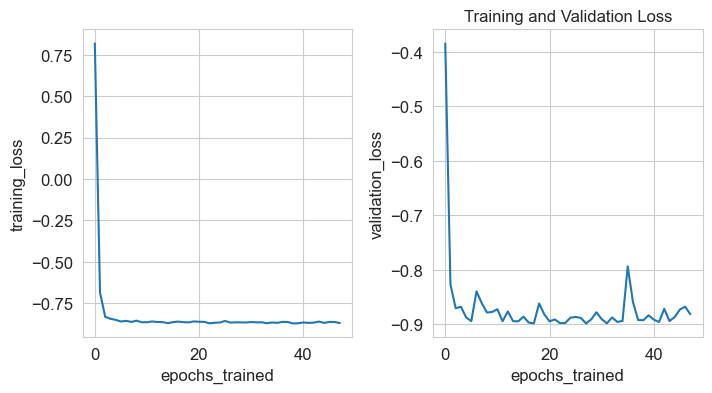

1098it [00:00, 56635.17it/s]            


In [36]:
posterior_1 = norm_example_npe_c(50000, 1, prior_torch, x_o_1, simulator_torch_1)

In [37]:
prior_a = 0.0
prior_b = 10.0
theta_grid = np.linspace(0, 10, 1000)
x_o_1_numpy = x_o_1.cpu().numpy()

prior = uniform.pdf(theta_grid, loc=prior_a, scale=(prior_b - prior_a))

likelihood = norm.pdf(x_o_1_numpy[0], loc=theta_grid, scale=0.1)

unnormalized_posterior = likelihood * prior
d_theta = theta_grid[1] - theta_grid[0]
posterior = unnormalized_posterior / (np.sum(unnormalized_posterior) * d_theta)

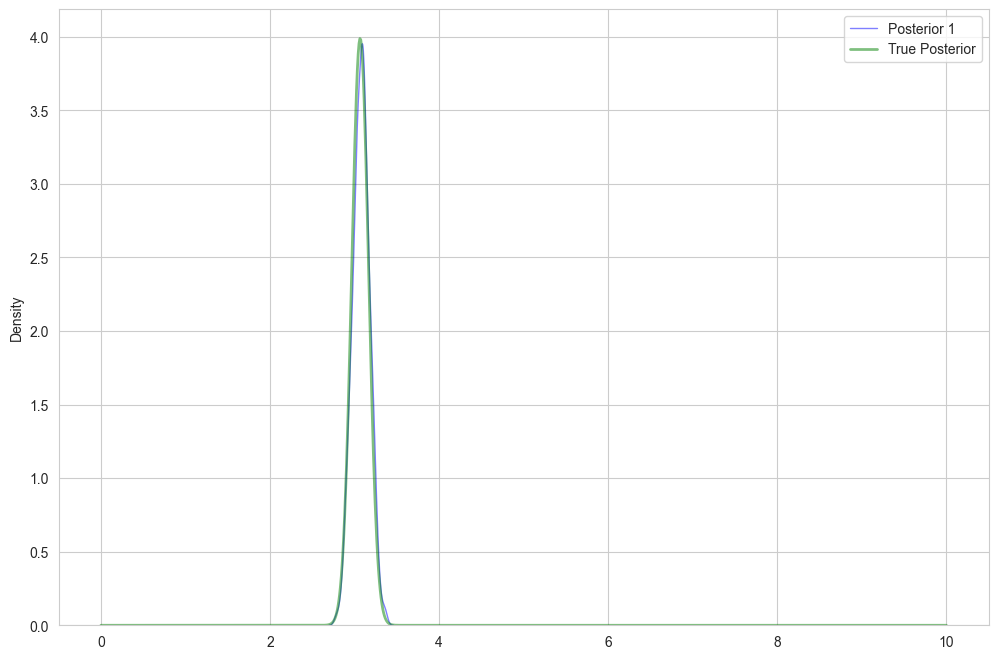

In [38]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(posterior_1[:, 0], label='Posterior 1', color='blue', linewidth=1, alpha=0.5)
plt.plot(theta_grid, posterior, label='True Posterior', color='green', linewidth=2, alpha=0.5)
plt.legend()
plt.show()